# Hälsostudie Del 2

I del 2 försöker jag strukturera koden lite bättre än i del 1.
Jag använder några funktioner, en enkel klass och en linjär regression
för att undersöka sambandet mellan blodtryck, ålder och vikt.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

np.random.seed(42)

# Läs in data (samma som i del 1)
df = pd.read_csv("data/health_study_dataset.csv")
df.head()


,id,age,sex,height,weight,systolic_bp,cholesterol,smoker,disease
0,1,57,F,168.9,65.8,141.8,4.58,No,0
1,2,47,M,180.4,95.9,144.8,5.18,Yes,0
2,3,59,F,169.9,82.2,151.7,6.16,No,0
3,4,72,M,157.7,93.1,151.0,6.63,No,0
4,5,46,M,192.6,104.1,144.1,5.21,No,0


## Funktioner

I del 1 skrev jag det mesta direkt i celler. Här lägger jag
lite av koden i funktioner i stället. Det gör att jag kan
anropa samma logik flera gånger utan att kopiera allt.

Jag börjar med en funktion som läser in data, en som räknar ut
beskrivande statistik och en som ritar ett histogram för blodtrycket.


In [4]:
def load_data(path="data/health_study_dataset.csv"):
    """
    Läser in hälsodatat från CSV och returnerar en DataFrame.
    """
    return pd.read_csv(path)


def basic_stats(df, cols=None):
    """
    Skriver ut enkel beskrivande statistik (medel, median, min, max)
    för valda kolumner.
    """
    if cols is None:
        cols = ["age", "weight", "height", "systolic_bp", "cholesterol"]
    for c in cols:
        mean_v = df[c].mean()
        med_v = df[c].median()
        min_v = df[c].min()
        max_v = df[c].max()
        print(f"{c}: medel={mean_v:.2f}, median={med_v:.2f}, min={min_v:.2f}, max={max_v:.2f}")


def plot_bp_hist(df):
    """
    Ritar ett enkelt histogram för systoliskt blodtryck.
    """
    plt.figure()
    plt.hist(df["systolic_bp"].dropna(), bins=15)
    plt.xlabel("Systoliskt blodtryck (mmHg)")
    plt.ylabel("Antal")
    plt.title("Histogram - systoliskt blodtryck")
    plt.show()


age: medel=49.43, median=50.00, min=18.00, max=90.00
weight: medel=73.41, median=73.20, min=33.70, max=114.40
height: medel=171.85, median=171.35, min=144.40, max=200.40
systolic_bp: medel=149.18, median=149.40, min=106.80, max=185.90
cholesterol: medel=4.93, median=4.97, min=2.50, max=7.88


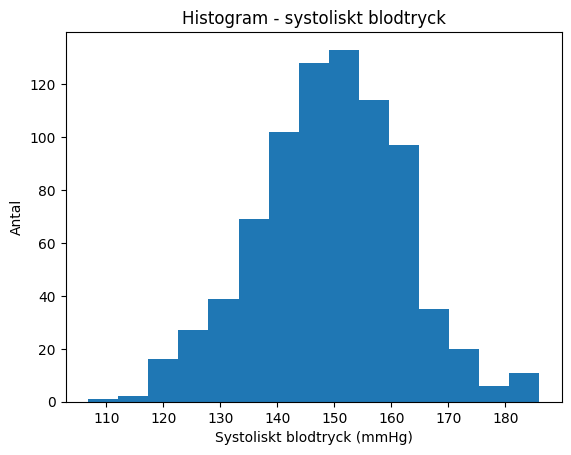

In [5]:
# Testar funktionerna snabbt
data_test = load_data()
basic_stats(data_test)
plot_bp_hist(data_test)


## Klass: HealthAnalyzer

För att strukturera koden lite mer gör jag också en enkel klass
som heter `HealthAnalyzer`. Tanken är att den ska hålla i
DataFrame:en och ha metoder för några analyser:

* skriva ut grundläggande statistik
* rita en boxplot för vikt per kön
* räkna sjukdomsförekomst per kön
* göra en linjär regression för blodtryck ~ ålder + vikt
* räkna ut ett enkelt R²-värde för modellen


In [6]:
class HealthAnalyzer:
    """
    En enkel klass för att analysera hälsodatat.
    """

    def __init__(self, df):
        """
        Tar emot en DataFrame och sparar den.
        """
        self.df = df
        self._bp_beta = None  # koefficienter för blodtrycksmodellen

    def print_basic_stats(self, cols=None):
        """
        Skriver ut grundläggande statistik för valda kolumner.
        """
        basic_stats(self.df, cols)

    def plot_weight_by_sex(self):
        """
        Ritar en boxplot med vikt uppdelad på kön.
        """
        plt.figure()
        self.df.boxplot(column="weight", by="sex")
        plt.suptitle("")  # tar bort extra titel
        plt.ylabel("Vikt (kg)")
        plt.title("Vikt per kön")
        plt.show()

    def disease_rate_by_sex(self):
        """
        Returnerar sjukdomsförekomst per kön som en liten tabell.
        """
        return self.df.groupby("sex")["disease"].mean()

    def fit_bp_regression(self):
        """
        Enkel linjär regression:
        systoliskt blodtryck ~ ålder + vikt.

        Jag bygger upp en designmatris X med:
        - en kolumn med ettor (intercept)
        - en kolumn med ålder
        - en kolumn med vikt

        Sedan använder jag numpy.linalg.lstsq för att hitta
        koefficienterna.
        """
        X = self.df[["age", "weight"]].values
        y = self.df["systolic_bp"].values

        # lägg till intercept-kolumn (ettor)
        ones = np.ones((X.shape[0], 1))
        X_design = np.hstack([ones, X])

        beta, _, _, _ = np.linalg.lstsq(X_design, y, rcond=None)
        self._bp_beta = beta
        return beta

    def predict_bp(self, age, weight):
        """
        Prognos av blodtryck för en given ålder och vikt.
        """
        if self._bp_beta is None:
            self.fit_bp_regression()
        b0, b_age, b_weight = self._bp_beta
        return b0 + b_age * age + b_weight * weight

    def bp_r2(self):
        """
        Räknar ut ett enkelt R²-värde för blodtrycksmodellen.
        """
        if self._bp_beta is None:
            self.fit_bp_regression()

        X = self.df[["age", "weight"]].values
        y = self.df["systolic_bp"].values
        ones = np.ones((X.shape[0], 1))
        X_design = np.hstack([ones, X])
        y_pred = X_design @ self._bp_beta

        ss_total = np.sum((y - y.mean())**2)
        ss_res = np.sum((y - y_pred)**2)
        r2 = 1 - ss_res / ss_total
        return r2


Grundläggande statistik:
age: medel=49.43, median=50.00, min=18.00, max=90.00
weight: medel=73.41, median=73.20, min=33.70, max=114.40
height: medel=171.85, median=171.35, min=144.40, max=200.40
systolic_bp: medel=149.18, median=149.40, min=106.80, max=185.90
cholesterol: medel=4.93, median=4.97, min=2.50, max=7.88

Sjukdomsförekomst per kön:
sex
F    0.044665
M    0.073048
Name: disease, dtype: float64


<Figure size 640x480 with 0 Axes>

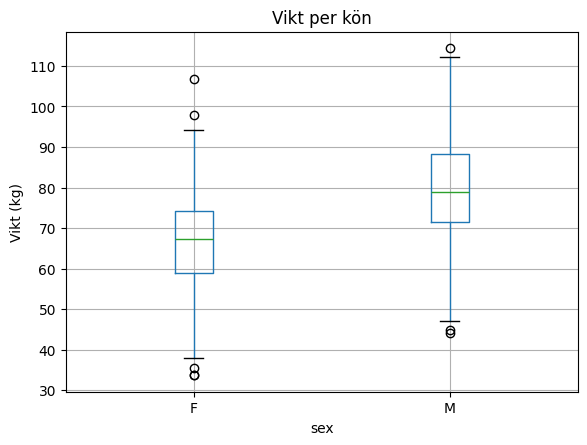


Koefficienter (intercept, ålder, vikt): [109.49908145   0.53892763   0.17765752]
R² för blodtrycksmodellen: 0.4052560814611623
Exempel: uppskattat blodtryck för 50 år, 80 kg: 150.65806482612726


In [7]:
# Skapar ett objekt av klassen och testar metoderna
analyzer = HealthAnalyzer(df)

print("Grundläggande statistik:")
analyzer.print_basic_stats()

print("\nSjukdomsförekomst per kön:")
print(analyzer.disease_rate_by_sex())

analyzer.plot_weight_by_sex()

beta = analyzer.fit_bp_regression()
r2 = analyzer.bp_r2()

print("\nKoefficienter (intercept, ålder, vikt):", beta)
print("R² för blodtrycksmodellen:", r2)

example_pred = analyzer.predict_bp(age=50, weight=80)
print("Exempel: uppskattat blodtryck för 50 år, 80 kg:", example_pred)


## Linjär algebra i praktiken blodtrycksmodell

Här använder jag en enkel linjär regression där jag försöker förklara
systoliskt blodtryck med två variabler: ålder och vikt.

Jag bygger upp en designmatris X som består av:

* en kolumn med bara ettor (intercept)
* en kolumn med ålder
* en kolumn med vikt

Sedan använder jag funktionen `numpy.linalg.lstsq` för att lösa
minstakvadratproblemet. Det ger mig koefficienter som talar om hur
mycket blodtrycket i genomsnitt ändras när ålder eller vikt ökar.

Detta är ett konkret exempel på hur matriser och vektorer används
för att bygga en statistisk modell i praktiken.


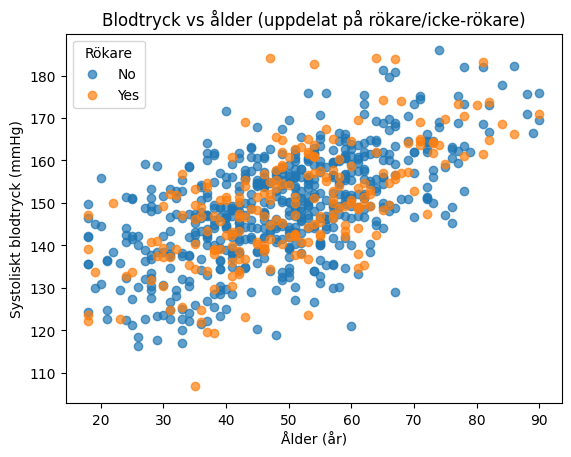

In [8]:
plt.figure()
for label, group in df.groupby("smoker"):
    plt.scatter(group["age"], group["systolic_bp"], label=label, alpha=0.7)

plt.xlabel("Ålder (år)")
plt.ylabel("Systoliskt blodtryck (mmHg)")
plt.title("Blodtryck vs ålder (uppdelat på rökare/icke-rökare)")
plt.legend(title="Rökare")
plt.show()


sex
F    0.044665
M    0.073048
Name: disease, dtype: float64


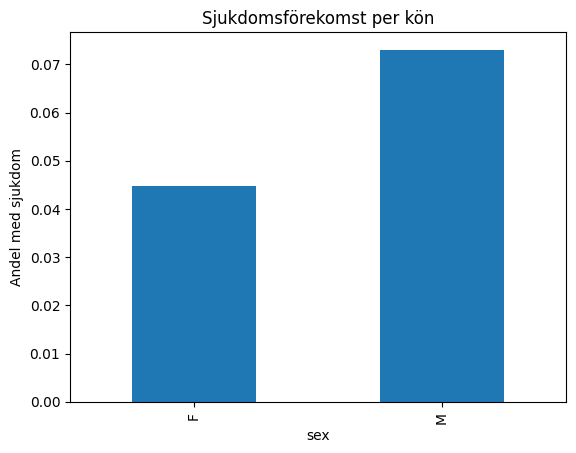

In [9]:
disease_by_sex = analyzer.disease_rate_by_sex()
print(disease_by_sex)

plt.figure()
disease_by_sex.plot(kind="bar")
plt.ylabel("Andel med sjukdom")
plt.title("Sjukdomsförekomst per kön")
plt.show()


## Sammanfattning och metodval i Del 2

I den här delen har jag försökt bygga vidare på del 1 men göra
koden lite mer strukturerad:

* Jag har lagt vissa delar i **funktioner** (t.ex. `basic_stats`
  och `plot_bp_hist`) så att jag kan återanvända dem.
* Jag har gjort en enkel **klass** `HealthAnalyzer` som håller i
  datan och har metoder för olika analyser och grafer.
* Jag använder en **linjär regression** där systoliskt blodtryck
  förklaras av ålder och vikt. Det bygger på matriser/vektorer och
  jag använder `numpy.linalg.lstsq` som finns dokumenterad i NumPy:s
  dokumentation.
* Jag har lagt till **extra grafer**, bland annat blodtryck mot ålder
  (uppdelat på rökare/icke-rökare) och sjukdomsförekomst per kön, för
  att få lite mer känsla för hur data ser ut.

Jag har försökt hålla metoderna ganska enkla och använda sådant vi
har gått igenom på kursen, tillsammans med grundläggande funktioner
från `numpy` och `pandas` som det är lätt att läsa mer om i deras
dokumentation.
